## Basic Setup no Pre-processing Done

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)


In [2]:
# UCI student performance (Portugal)
uci = pd.read_csv("uci_combined_students.csv")

# xAPI education data (Middle East context)
xapi = pd.read_csv("xAPI-Edu-Data.csv")

print("UCI shape:", uci.shape)
print("xAPI shape:", xapi.shape)

uci.head(), xapi.head()


UCI shape: (1044, 34)
xAPI shape: (480, 17)


(  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  \
 0     GP   F   18       U     GT3       A     4     4  at_home   teacher   
 1     GP   F   17       U     GT3       T     1     1  at_home     other   
 2     GP   F   15       U     LE3       T     1     1  at_home     other   
 3     GP   F   15       U     GT3       T     4     2   health  services   
 4     GP   F   16       U     GT3       T     3     3    other     other   
 
    reason guardian  traveltime  studytime  failures schoolsup famsup paid  \
 0  course   mother           2          2         0       yes     no   no   
 1  course   father           1          2         0        no    yes   no   
 2   other   mother           1          2         3       yes     no  yes   
 3    home   mother           1          3         0        no    yes  yes   
 4    home   father           1          2         0        no    yes  yes   
 
   activities nursery higher internet romantic  famrel  freetime  

In [3]:
# --- UCI dataset: performance score ---
# G3 is final grade (0–20). Convert to percentage (0–100).
uci = uci.copy()
uci['perf_raw'] = uci['G3']
uci['perf_pct'] = uci['G3'] / 20 * 100
uci['country'] = "Portugal"

# --- xAPI dataset: performance score ---
xapi = xapi.copy()
class_map = {'L': 0, 'M': 1, 'H': 2}
xapi['perf_raw'] = xapi['Class'].map(class_map)

# scale 0,1,2 into 0–100 (0, 50, 100) just to compare shape
xapi['perf_pct'] = xapi['perf_raw'] / 2 * 100
xapi['country'] = "MiddleEast"

# Quick check
uci[['G3', 'perf_pct']].head(), xapi[['Class', 'perf_raw', 'perf_pct']].head()


(   G3  perf_pct
 0   6      30.0
 1   6      30.0
 2  10      50.0
 3  15      75.0
 4  10      50.0,
   Class  perf_raw  perf_pct
 0     M         1      50.0
 1     M         1      50.0
 2     L         0       0.0
 3     L         0       0.0
 4     M         1      50.0)

## Compare Academic Performance Patterns Across Two Countries

In [4]:
# Align columns for comparison
uci_small = uci[['country', 'sex', 'age', 'absences', 'perf_raw', 'perf_pct']].rename(
    columns={'sex': 'gender', 'absences': 'absences_num'}
)

# Map xAPI gender to F/M style if you want consistency (already M/F)
# Convert StudentAbsenceDays to numeric flag: 0 = Under-7, 1 = Above-7
absence_map = {'Under-7': 0, 'Above-7': 1}
xapi['absences_num'] = xapi['StudentAbsenceDays'].map(absence_map)

xapi_small = xapi[['country', 'gender', 'absences_num', 'perf_raw', 'perf_pct']]

combined = pd.concat([uci_small, xapi_small], ignore_index=True)

combined.head()


,country,gender,age,absences_num,perf_raw,perf_pct
0,Portugal,F,18.0,6,6,30.0
1,Portugal,F,17.0,4,6,30.0
2,Portugal,F,15.0,10,10,50.0
3,Portugal,F,15.0,2,15,75.0
4,Portugal,F,16.0,4,10,50.0


In [7]:
# Summary stats by country  (fixed)
combined.groupby('country')[['perf_raw', 'perf_pct']].describe()


perf_raw                                                    \
              count       mean       std  min   25%   50%   75%   max   
country                                                                 
MiddleEast    480.0   1.031250  0.748738  0.0   0.0   1.0   2.0   2.0   
Portugal     1044.0  11.341954  3.864796  0.0  10.0  11.0  14.0  20.0   

           perf_pct                                                      
              count      mean        std  min   25%   50%    75%    max  
country                                                                  
MiddleEast    480.0  51.56250  37.436881  0.0   0.0  50.0  100.0  100.0  
Portugal     1044.0  56.70977  19.323979  0.0  50.0  55.0   70.0  100.0

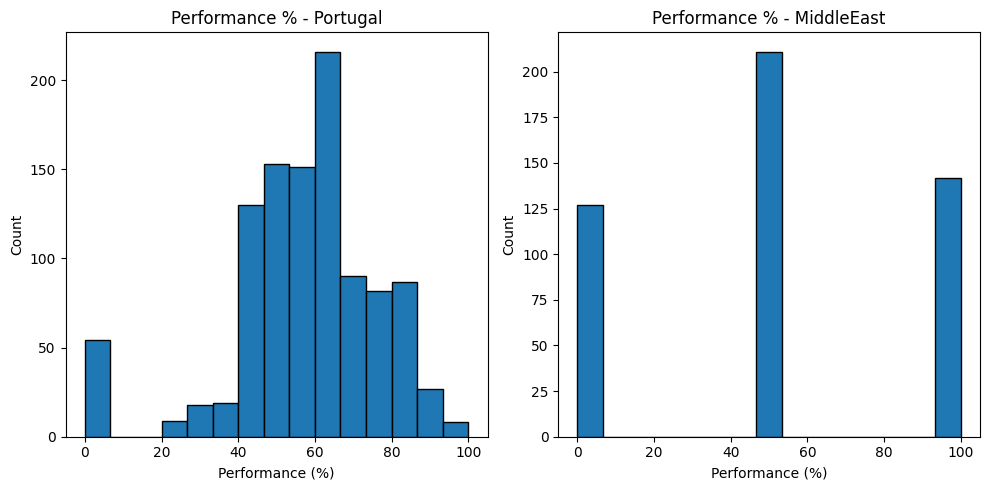

In [9]:
# Histograms of performance % by country
plt.figure(figsize=(10, 5))

for i, country in enumerate(combined['country'].unique(), 1):
    plt.subplot(1, 2, i)
    subset = combined[combined['country'] == country]
    plt.hist(subset['perf_pct'], bins=15, edgecolor='black')
    plt.title(f"Performance % - {country}")
    plt.xlabel("Performance (%)")
    plt.ylabel("Count")

plt.tight_layout()
plt.show()


In [11]:
# Mean performance by gender and country
gender_country_perf = combined.groupby(['country', 'gender'])['perf_pct'].agg(['mean', 'count']).reset_index()
gender_country_perf


,country,gender,mean,count
0,MiddleEast,F,64.571429,175
1,MiddleEast,M,44.098361,305
2,Portugal,F,57.241963,591
3,Portugal,M,56.015453,453


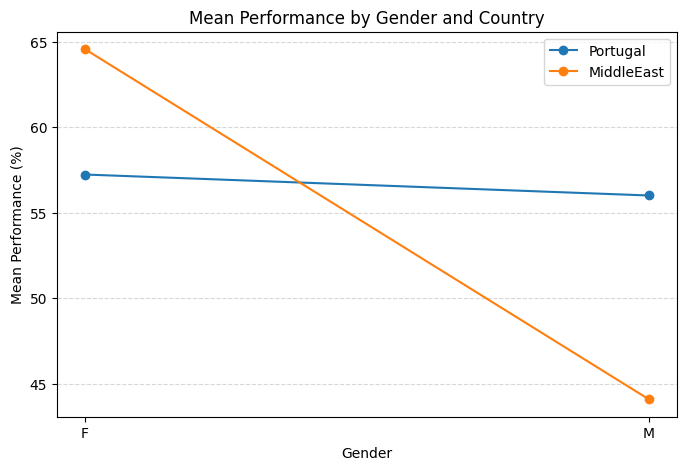

In [13]:
# Bar chart: mean performance by gender for each country
countries = combined['country'].unique()

plt.figure(figsize=(8, 5))

for country in countries:
    subset = gender_country_perf[gender_country_perf['country'] == country]
    plt.plot(subset['gender'], subset['mean'], marker='o', label=country)

plt.xlabel("Gender")
plt.ylabel("Mean Performance (%)")
plt.title("Mean Performance by Gender and Country")
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.show()


In [15]:
# UCI: relationship between numeric absences and performance
uci[['absences', 'perf_pct']].corr()


,absences,perf_pct
absences,1.000000,-0.045671
perf_pct,-0.045671,1.000000


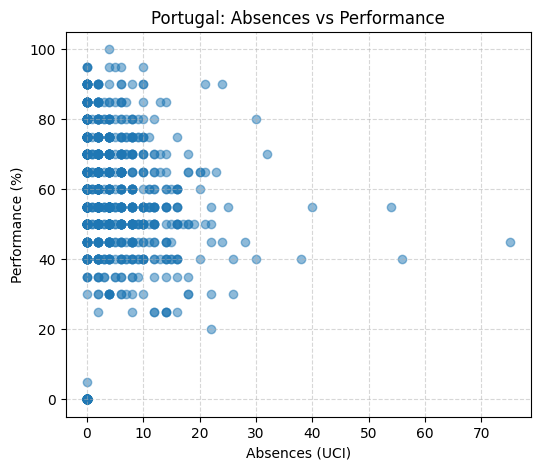

In [17]:
plt.figure(figsize=(6, 5))
plt.scatter(uci['absences'], uci['perf_pct'], alpha=0.5)
plt.xlabel("Absences (UCI)")
plt.ylabel("Performance (%)")
plt.title("Portugal: Absences vs Performance")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


In [19]:
# xAPI: absence category vs performance
xapi.groupby('StudentAbsenceDays')['perf_pct'].agg(['mean', 'count'])


,mean,count
StudentAbsenceDays,,
Above-7,20.680628,191
Under-7,71.972318,289


<Figure size 600x500 with 0 Axes>

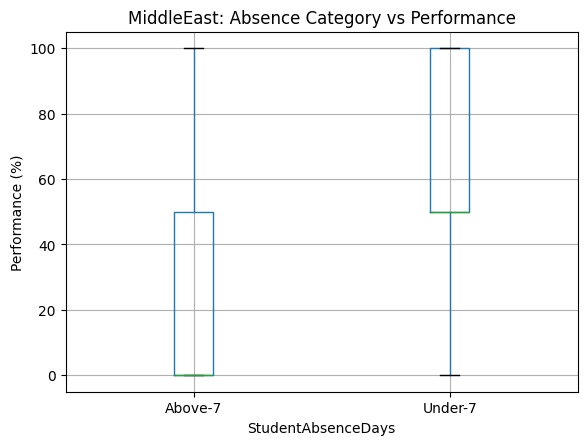

In [21]:
plt.figure(figsize=(6, 5))
xapi_box = xapi[['StudentAbsenceDays', 'perf_pct']].copy()
xapi_box.boxplot(by='StudentAbsenceDays', column='perf_pct')
plt.suptitle("")  # remove automatic title
plt.title("MiddleEast: Absence Category vs Performance")
plt.xlabel("StudentAbsenceDays")
plt.ylabel("Performance (%)")
plt.show()


In [23]:
summary_table = combined.groupby('country')['perf_pct'].agg(
    mean_perf='mean',
    median_perf='median',
    std_perf='std',
    min_perf='min',
    max_perf='max'
).round(2)

summary_table


,mean_perf,median_perf,std_perf,min_perf,max_perf
country,,,,,
MiddleEast,51.56,50.0,37.44,0.0,100.0
Portugal,56.71,55.0,19.32,0.0,100.0


## Absenteeism Impact 

#### UCI Dataset — Absences vs Final Grade (G3)

UCI Correlation (Absences vs Performance): -0.0457


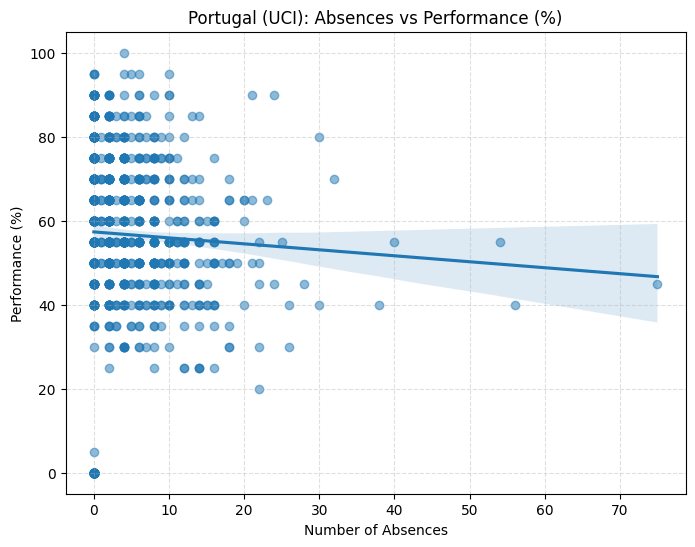

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# UCI absences vs performance
uci_abs = uci[['absences', 'perf_pct']].copy()

corr_uci = uci_abs.corr().iloc[0,1]
print("UCI Correlation (Absences vs Performance):", round(corr_uci, 4))

plt.figure(figsize=(8,6))
sns.regplot(x='absences', y='perf_pct', data=uci_abs, scatter_kws={'alpha':0.5})
plt.title("Portugal (UCI): Absences vs Performance (%)")
plt.xlabel("Number of Absences")
plt.ylabel("Performance (%)")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()


### xAPI Dataset — Absence Category vs Performance (Boxplot)

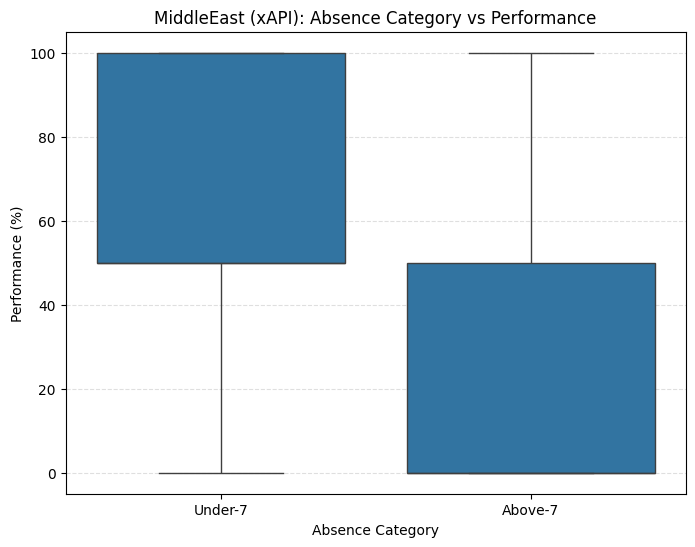

In [34]:
plt.figure(figsize=(8,6))
sns.boxplot(x='StudentAbsenceDays', y='perf_pct', data=xapi)
plt.title("MiddleEast (xAPI): Absence Category vs Performance")
plt.xlabel("Absence Category")
plt.ylabel("Performance (%)")
plt.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.show()


In [36]:
# Convert absence category to numeric (0 = Under-7, 1 = Above-7)
absence_map = {'Under-7': 0, 'Above-7': 1}
xapi['absences_num'] = xapi['StudentAbsenceDays'].map(absence_map)

corr_xapi = xapi[['absences_num', 'perf_pct']].corr().iloc[0,1]
print("xAPI Correlation (Absence Category vs Performance):", round(corr_xapi, 4))


xAPI Correlation (Absence Category vs Performance): -0.6713


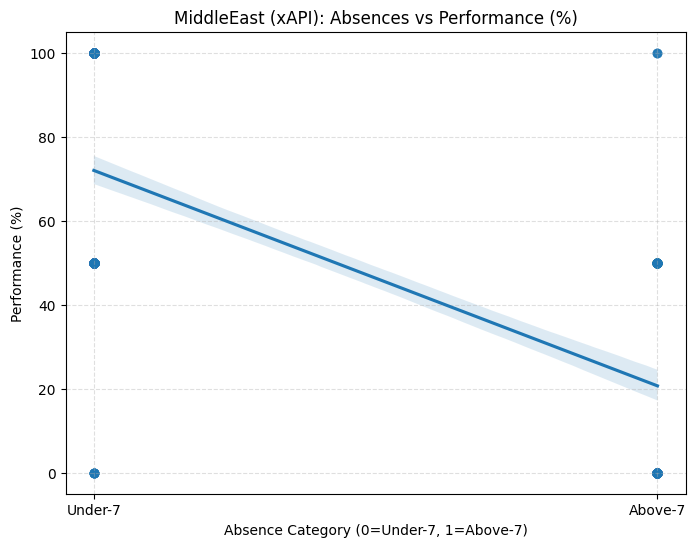

In [38]:
plt.figure(figsize=(8,6))
sns.regplot(x='absences_num', y='perf_pct', data=xapi, scatter_kws={'alpha':0.5})
plt.xticks([0,1], ['Under-7', 'Above-7'])
plt.title("MiddleEast (xAPI): Absences vs Performance (%)")
plt.xlabel("Absence Category (0=Under-7, 1=Above-7)")
plt.ylabel("Performance (%)")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()


In [40]:
summary_absenteeism = pd.DataFrame({
    'Dataset': ['Portugal (UCI)', 'MiddleEast (xAPI)'],
    'Correlation Absence→Performance': [corr_uci, corr_xapi]
})

summary_absenteeism


,Dataset,Correlation Absence→Performance
0,Portugal (UCI),-0.045671
1,MiddleEast (xAPI),-0.671312


### Gender-Based Analysis

In [45]:
# Mean performance by gender for both datasets
gender_perf = combined.groupby(['country', 'gender'])['perf_pct'].agg(['mean', 'count']).reset_index()
gender_perf


,country,gender,mean,count
0,MiddleEast,F,64.571429,175
1,MiddleEast,M,44.098361,305
2,Portugal,F,57.241963,591
3,Portugal,M,56.015453,453


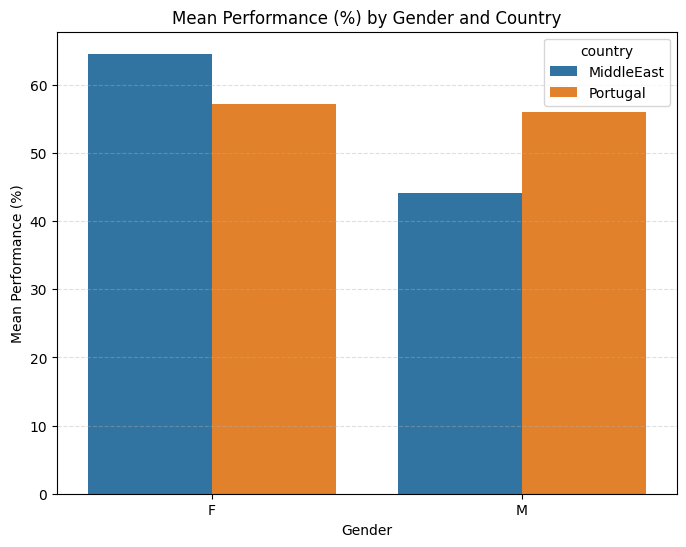

In [47]:
plt.figure(figsize=(8,6))
sns.barplot(data=gender_perf, x='gender', y='mean', hue='country')
plt.title("Mean Performance (%) by Gender and Country")
plt.xlabel("Gender")
plt.ylabel("Mean Performance (%)")
plt.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.show()


In [49]:
uci_gender_abs = uci.groupby('sex')['absences'].mean().reset_index()
uci_gender_abs.rename(columns={'sex':'gender', 'absences':'mean_absences'}, inplace=True)
uci_gender_abs


,gender,mean_absences
0,F,4.505922
1,M,4.342163


In [51]:
xapi_gender_abs = xapi.groupby('gender')['absences_num'].mean().reset_index()
xapi_gender_abs.rename(columns={'absences_num':'mean_absences'}, inplace=True)
xapi_gender_abs


,gender,mean_absences
0,F,0.262857
1,M,0.475410


### Plot: Absences by Gender (Both Countries)

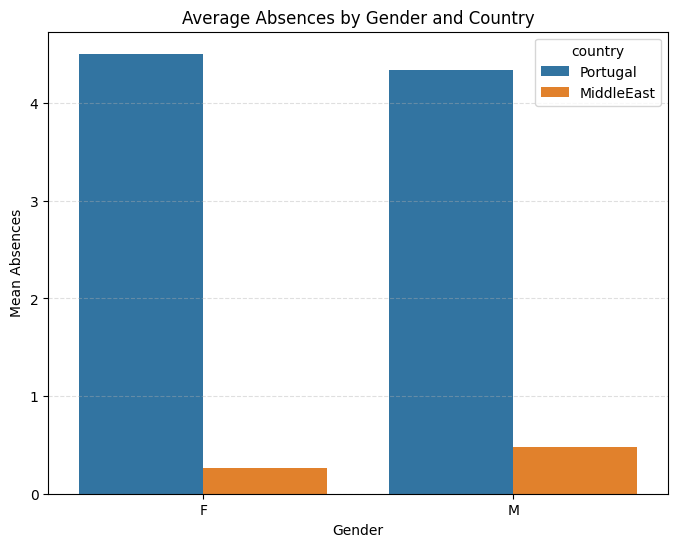

In [53]:
# Combine into one table
uci_gender_abs['country'] = 'Portugal'
xapi_gender_abs['country'] = 'MiddleEast'

abs_combined = pd.concat([uci_gender_abs, xapi_gender_abs], ignore_index=True)

plt.figure(figsize=(8,6))
sns.barplot(data=abs_combined, x='gender', y='mean_absences', hue='country')
plt.title("Average Absences by Gender and Country")
plt.xlabel("Gender")
plt.ylabel("Mean Absences")
plt.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.show()


### Box Plot: Performance by Gender

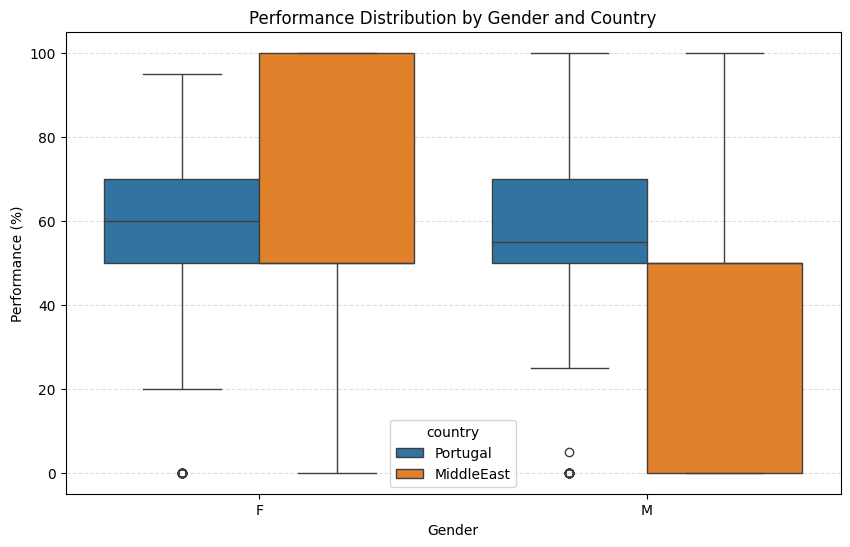

In [58]:
plt.figure(figsize=(10,6))
sns.boxplot(data=combined, x='gender', y='perf_pct', hue='country')
plt.title("Performance Distribution by Gender and Country")
plt.xlabel("Gender")
plt.ylabel("Performance (%)")
plt.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.show()


### Distribution Plot: Performance by Gender

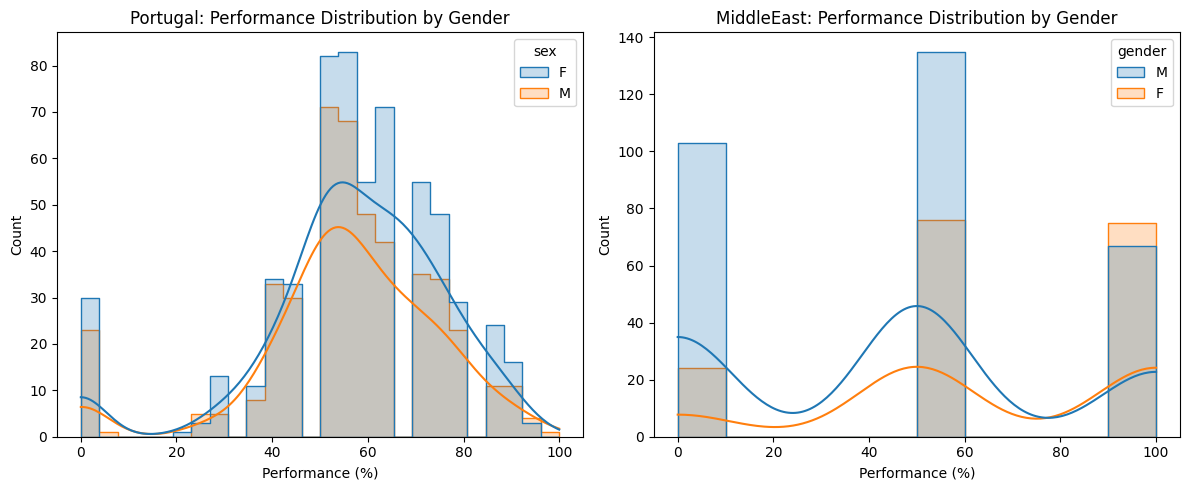

In [60]:
plt.figure(figsize=(12,5))

# Portugal
plt.subplot(1,2,1)
sns.histplot(data=uci, x='perf_pct', hue='sex', kde=True, element='step')
plt.title("Portugal: Performance Distribution by Gender")
plt.xlabel("Performance (%)")

# MiddleEast
plt.subplot(1,2,2)
sns.histplot(data=xapi, x='perf_pct', hue='gender', kde=True, element='step')
plt.title("MiddleEast: Performance Distribution by Gender")
plt.xlabel("Performance (%)")

plt.tight_layout()
plt.show()


### Comparison Table

In [62]:
gender_summary = pd.DataFrame({
    "Country": [],
    "Gender": [],
    "Mean Performance (%)": [],
    "Mean Absences": []
})

# Portugal
for g in uci['sex'].unique():
    gender_summary.loc[len(gender_summary)] = [
        "Portugal",
        g,
        round(uci[uci['sex'] == g]['perf_pct'].mean(), 2),
        round(uci[uci['sex'] == g]['absences'].mean(), 2)
    ]

# Middle East
for g in xapi['gender'].unique():
    gender_summary.loc[len(gender_summary)] = [
        "MiddleEast",
        g,
        round(xapi[xapi['gender'] == g]['perf_pct'].mean(), 2),
        round(xapi[xapi['gender'] == g]['absences_num'].mean(), 2)
    ]

gender_summary


,Country,Gender,Mean Performance (%),Mean Absences
0,Portugal,F,57.24,4.51
1,Portugal,M,56.02,4.34
2,MiddleEast,M,44.10,0.48
3,MiddleEast,F,64.57,0.26
